# Testing the 21cmFast Output Volume

## Initialisation

In [1]:
# Import python modules
import os
import sys
import numpy as np
from matplotlib import pyplot as plt, colors
from astropy import units as u, constants as c
from astropy.cosmology import FlatLambdaCDM as fmodel, z_at_value as getz
import h5py
#import py21cmfast as p21c
import json

# Import local oskareor models
sys.path.append("..")
from oskareor.skalow_calc import SKAMath as omath, EoRCosmology as Cosmo, FileManager as ofmg

In [2]:
# EoR colour map
EoR_colour = colors.LinearSegmentedColormap.from_list('mycmap',
    [(0, 'white'),(0.125, 'yellow'),(0.25, 'orange'),(0.325, 'red'),\
    (0.5, 'black'),(0.75, 'blue'),(1, 'cyan')])

eor_cmap = {
    "map": EoR_colour,
    "norm": colors.TwoSlopeNorm(0, -160, 40),
    "ticks": np.arange(-160, 41, 20),
    "bounds": np.linspace(-160, 40, 257),
    "dist": "uniform"
}

In [3]:
# Import the h5 File Data
path = ofmg.expand_path("~/oskareor.data/simulations/project1/q25_lightcone_simulation.h5")
file = h5py.File(path)
data = np.array(file['lightcones']['brightness_temp'])
dist = np.array(file['lightcone_distances'])
inpd = file['InputParameters']

print(list(file))
print(dist)

['InputParameters', 'global_quantities', 'lightcone_distances', 'lightcones', 'photon_nonconservation_data']
[ 8199.58630587  8201.53943087  8203.49255587 ... 10193.72693087
 10195.68005587 10197.63318087]


In [4]:
def hdf5_to_dict(grp):
    """Load all data from an HDF5 Group into a dict.

    Essentially the same as toml.load() but for HDF5.
    """
    out = dict(grp.attrs)

    for k, v in grp.items():
        if isinstance(v, h5py.Group):
            out[k] = hdf5_to_dict(v)
        else:
            out[k] = v[()]

    return out

print(json.dumps(hdf5_to_dict(inpd), indent=4, sort_keys=True, default=str))
inpd = hdf5_to_dict(inpd)

{
    "21cmFAST-version": "4.2",
    "astro_options": {
        "CELL_RECOMB": "False",
        "FIX_VCB_AVG": "False",
        "HALO_SCALING_RELATIONS_MEDIAN": "False",
        "HEAT_FILTER": "spherical-tophat",
        "HII_FILTER": "sharp-k",
        "INTEGRATION_METHOD_ATOMIC": "GAUSS-LEGENDRE",
        "INTEGRATION_METHOD_MINI": "GAUSS-LEGENDRE",
        "IONISE_ENTIRE_SPHERE": "False",
        "LYA_MULTIPLE_SCATTERING": "False",
        "M_MIN_in_Mass": "True",
        "PHOTON_CONS_TYPE": "z-photoncons",
        "RECOMB_MODEL": "inhomogeneous",
        "USE_ADIABATIC_FLUCTUATIONS": "True",
        "USE_CMB_HEATING": "True",
        "USE_EXP_FILTER": "False",
        "USE_LYA_HEATING": "True",
        "USE_MINI_HALOS": "False",
        "USE_TS_FLUCT": "True",
        "USE_UPPER_STELLAR_TURNOVER": "False",
        "USE_X_RAY_HEATING": "True"
    },
    "astro_params": {
        "ALPHA_ESC": -0.46,
        "ALPHA_STAR": 0.51,
        "ALPHA_STAR_MINI": 0.51,
        "ALPHA_UVB": 5.0

In [5]:
print(data.shape)

(250, 250, 1024)


In [6]:
# Cosmology data
cosmo = Cosmo(inpd["cosmo_params"]["hlittle"] * 100, inpd["cosmo_params"]["OMm"], inpd["cosmo_params"]["OMb"]).cosmo
btzs = getz(cosmo.comoving_distance, dist * u.Mpc).to_value()
print(btzs)

[ 5.46889112  5.47294527  5.4770032  ... 12.94982381 12.96261766
 12.9754291 ]


## Global Parameters

Printing global parameters against the node redshifts.

In [7]:
print(list(file['global_quantities']))

['brightness_temp', 'cumulative_recombinations', 'density', 'ionisation_rate_G12', 'kinetic_temp_neutral', 'kinetic_temperature', 'log10_mturn_acg', 'log10_mturn_mcg', 'mean_free_path', 'neutral_fraction', 'spin_temperature', 'tau_21', 'unnormalised_nion', 'velocity_z', 'xray_ionised_fraction', 'z_reion']


In [8]:
nzs = np.array(inpd["node_redshifts"])
gtbs = np.array(file['global_quantities']['brightness_temp'])
xh1s = np.array(file['global_quantities']['neutral_fraction'])

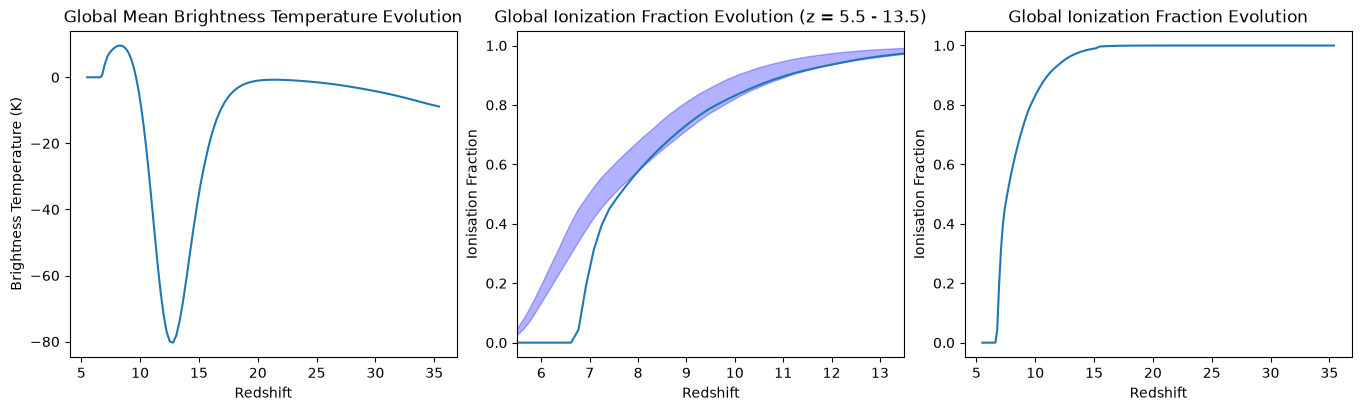

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, layout="constrained")
fig.set_size_inches((13.5, 4))

ax[0].plot(nzs, gtbs)
ax[0].set_xlabel("Redshift")
ax[0].set_ylabel("Brightness Temperature (K)")
ax[0].set_title("Global Mean Brightness Temperature Evolution")

Qin25_constf_xHI_upper = np.array([[5.0, 0],
[5.109677419354838, 0],
[5.251612903225807, 0.008426966292134797],
[5.419354838709678, 0.028089887640449396],
[5.574193548387097, 0.06179775280898869],
[5.729032258064516, 0.1039325842696629],
[5.870967741935484, 0.1488764044943819],
[5.948387096774194, 0.1741573033707864],
[6.090322580645161, 0.2219101123595505],
[6.193548387096774, 0.2584269662921348],
[6.296774193548387, 0.292134831460674],
[6.4, 0.3258426966292134],
[6.47741935483871, 0.3567415730337077],
[6.55483870967742, 0.3848314606741572],
[6.683870967741935, 0.4213483146067415],
[6.787096774193549, 0.4550561797752808],
[6.916129032258064, 0.4831460674157302],
[7.058064516129033, 0.5168539325842696],
[7.251612903225807, 0.5561797752808988],
[7.419354838709678, 0.5842696629213482],
[7.587096774193548, 0.6123595505617977],
[7.716129032258065, 0.6320224719101123],
[7.819354838709678, 0.648876404494382],
[7.974193548387097, 0.6713483146067415],
[8.103225806451613, 0.6910112359550561],
[8.270967741935484, 0.7134831460674156],
[8.477419354838709, 0.74438202247191],
[8.606451612903225, 0.7612359550561797],
[8.748387096774195, 0.7808988764044943],
[8.95483870967742, 0.8033707865168538],
[9.109677419354838, 0.8202247191011235],
[9.238709677419354, 0.8342696629213482],
[9.36774193548387, 0.845505617977528],
[9.496774193548386, 0.8567415730337078],
[9.625806451612902, 0.8679775280898876],
[9.832258064516129, 0.8848314606741572],
[9.98709677419355, 0.896067415730337],
[10.283870967741935, 0.9129213483146066],
[10.541935483870965, 0.9269662921348314],
[10.864516129032257, 0.9410112359550561],
[11.174193548387098, 0.9522471910112359],
[11.561290322580646, 0.9634831460674156],
[11.974193548387099, 0.9719101123595505],
[12.361290322580647, 0.9789325842696628],
[12.825806451612905, 0.9845505617977527],
[13.29032258064516, 0.9887640449438202],
[13.961290322580645, 0.9929775280898876],
[14, 1]])

Qin25_constf_xHI_lower = np.array([[5.0, 0],
[5.006451612903225, 0],
[5.264516129032257, 0],
[5.445161290322581, 0.01685393258426937],
[5.574193548387097, 0.033707865168539186],
[5.703225806451613, 0.05617977528089879],
[5.832258064516129, 0.08707865168539308],
[5.948387096774193, 0.11797752808988748],
[6.180645161290323, 0.1797752808988763],
[6.4387096774193555, 0.25],
[6.683870967741935, 0.3146067415730336],
[6.838709677419355, 0.3567415730337077],
[6.993548387096775, 0.396067415730337],
[7.12258064516129, 0.4269662921348314],
[7.303225806451613, 0.4634831460674157],
[7.458064516129032, 0.4915730337078651],
[7.587096774193548, 0.5140449438202246],
[7.806451612903226, 0.547752808988764],
[8.038709677419355, 0.5814606741573033],
[8.283870967741937, 0.6179775280898876],
[8.567741935483872, 0.6573033707865168],
[8.851612903225806, 0.693820224719101],
[9.135483870967743, 0.7303370786516853],
[9.44516129032258, 0.7668539325842696],
[9.858064516129033, 0.8061797752808988],
[10.193548387096774, 0.8370786516853932],
[10.70967741935484, 0.8735955056179774],
[11.303225806451614, 0.9073033707865168],
[11.84516129032258, 0.9297752808988763],
[12.593548387096774, 0.9522471910112359],
[13.019354838709678, 0.9606741573033707],
[13.41935483870968, 0.9691011235955055],
[13.832258064516129, 0.9747191011235954],
[14.0, 0.9761235955056179]])
global_xHI=np.zeros([2, len(nzs)])
global_xHI[0] = np.interp(nzs, Qin25_constf_xHI_lower[:,0], Qin25_constf_xHI_lower[:,1])
global_xHI[1] = np.interp(nzs, Qin25_constf_xHI_upper[:,0], Qin25_constf_xHI_upper[:,1])

ax[1].fill_between(nzs,global_xHI[0], global_xHI[1], alpha=0.3, color='blue', label='Qin+25')

ax[1].plot(nzs, xh1s)
ax[1].set_xlim(5.5, 13.5)
ax[1].set_xlabel("Redshift")
ax[1].set_ylabel("Ionisation Fraction")
ax[1].set_title("Global Ionization Fraction Evolution (z = 5.5 - 13.5)")

ax[2].plot(nzs, xh1s)
ax[2].set_xlabel("Redshift")
ax[2].set_ylabel("Ionisation Fraction")
ax[2].set_title("Global Ionization Fraction Evolution")

plt.show()

## Transverse Dimension Snapshots

Now we will see different snapshots of the saved lightcone volume at different redshifts.

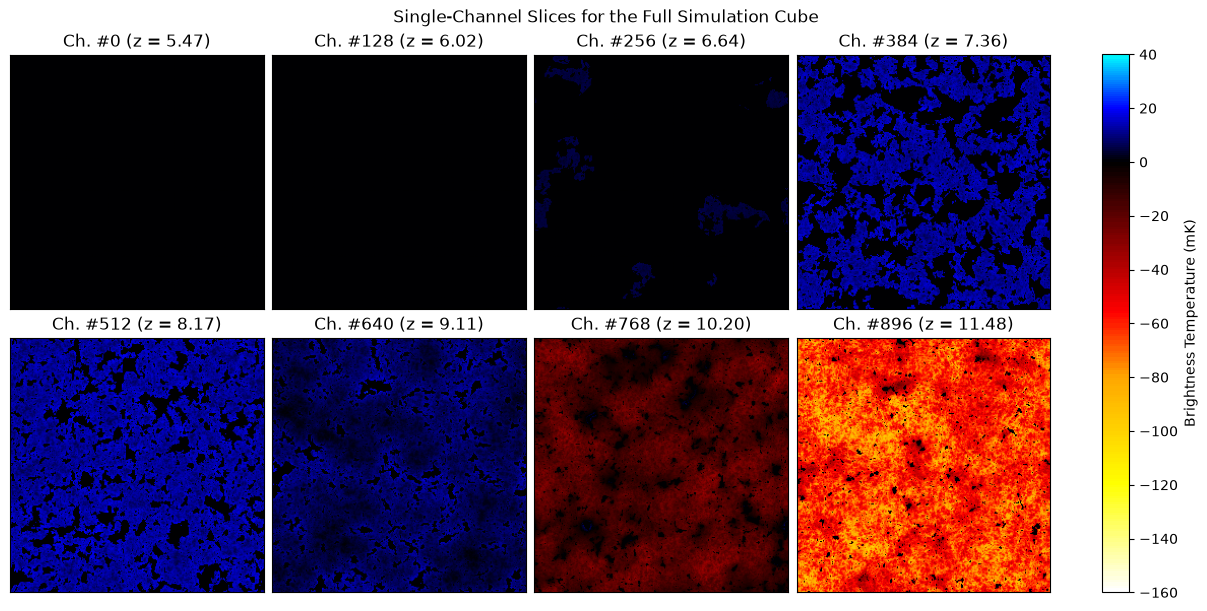

In [10]:
channels = np.arange(8) * 128

fig, ax = plt.subplots(nrows=2, ncols=4, layout="constrained", squeeze=True)
fig.set_size_inches((12,6))
ax = ax.flatten()

fig.suptitle("Single-Channel Slices for the Full Simulation Cube")

for i, chn in enumerate(channels):
    im = ax[i].imshow(data[:,:,chn], cmap=eor_cmap["map"], norm=eor_cmap["norm"])
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(f"Ch. #{chn} (z = {btzs[chn]:3.2f})")


fig.colorbar(im, ax=ax.ravel().tolist(), label="Brightness Temperature (mK)", boundaries=eor_cmap["bounds"], spacing=eor_cmap["dist"], ticks=eor_cmap["ticks"])

plt.show()


## Plotting Lightcones

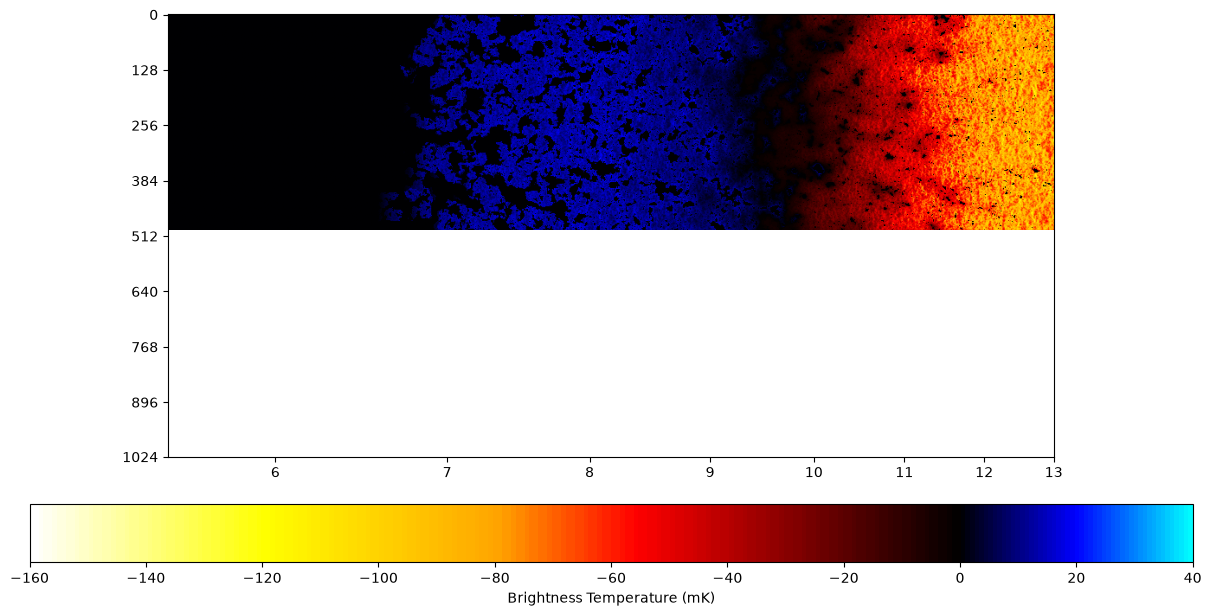

In [ ]:
def custom_image_ticks(values, labels):
    scales = np.interp(labels, values, np.arange(values.shape[0]))
    return scales, labels

fig, ax = plt.subplots(layout="constrained")
fig.set_size_inches((12,6))

im = ax.imshow(data[:,256,:], cmap=eor_cmap["map"], norm=eor_cmap["norm"])

ax.set_xticks(*custom_image_ticks(btzs, np.arange(6, 14, 1)))
ax.set_yticks(*custom_image_ticks(np.arange(512)*2, np.arange(0, 1025, 128)))

nrows, ncols = im.get_size()
aspect_ratio = ncols / nrows
fig.colorbar(im, ax=ax, label="Brightness Temperature (mK)", boundaries=eor_cmap["bounds"], spacing=eor_cmap["dist"], ticks=eor_cmap["ticks"], orientation="horizontal", fraction=0.05 * aspect_ratio, pad=0.04)

plt.show()